<a href="https://colab.research.google.com/github/Kethmika2004/Neural-Network-SMS-Spam-Classifier/blob/main/Neural_Network_SMS_Spam_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Network SMS Spam Classifier**



---



This project uses Natural Language Processing (NLP) and Deep Learning to classify SMS messages as either "ham" (legitimate) or "spam" (unwanted advertisements). By leveraging a Bidirectional LSTM neural network, the model understands the sequential context of words to accurately identify spam patterns. The pipeline includes text vectorization, model training with early stopping to prevent overfitting, performance visualization, and a real-time prediction function.


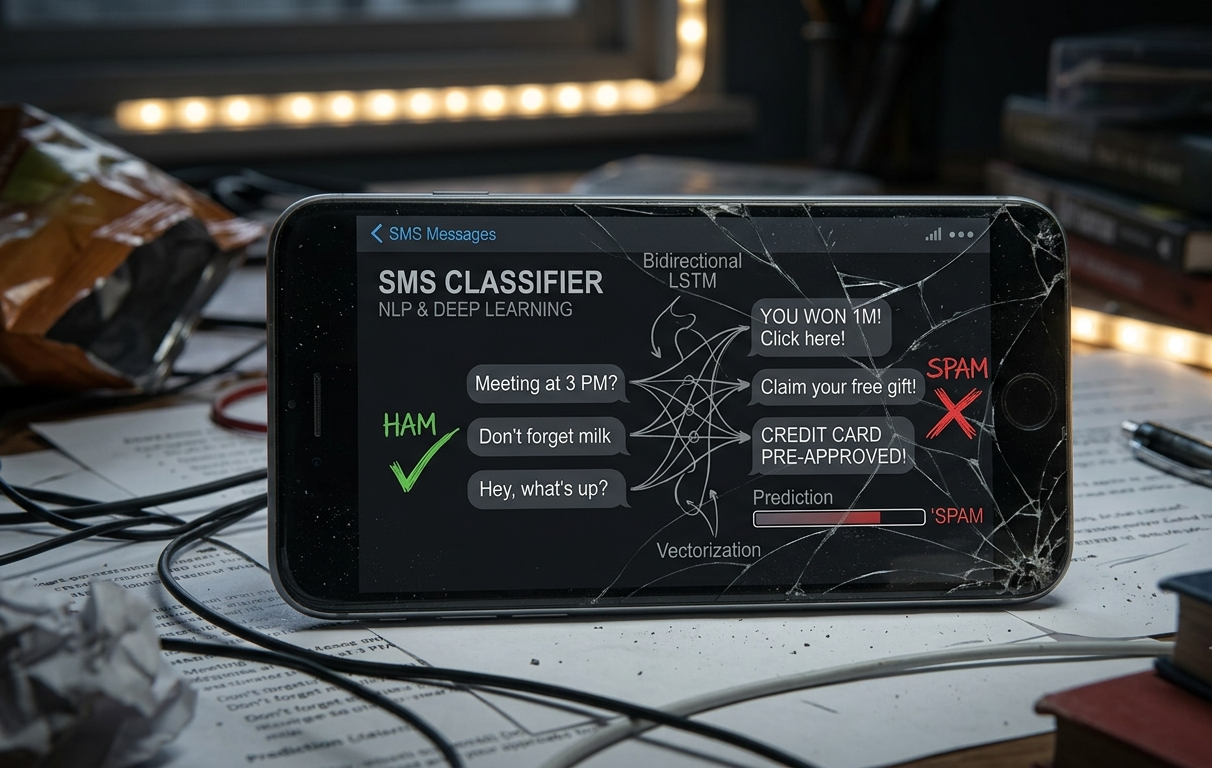

### **1: Setup and Imports**


We import necessary libraries. We also install stable TensorFlow to avoid the ```tf-nightly``` bugs, and ```scikit-learn``` for advanced evaluation metrics.

In [1]:
# Install stable TensorFlow instead of tf-nightly to avoid C-extension errors
!pip install tensorflow
!pip install scikit-learn

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### **2: Data Loading & Exploration (EDA)**


Before training, a data scientist always explores the data. We check the shape and look at the class balance (ham vs. spam), which is crucial for understanding if our model might become biased.

In [2]:
# get data files
!wget https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
!wget https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv

train_file_path = "train-data.tsv"
test_file_path = "valid-data.tsv"

# Load data
train_df = pd.read_csv(train_file_path, sep='\t', header=None, names=['label', 'message'])
test_df = pd.read_csv(test_file_path, sep='\t', header=None, names=['label', 'message'])

# Exploratory Data Analysis (EDA)
print("Dataset Info:")
print(train_df.info())
print("\nClass Distribution:")
print(train_df['label'].value_counts())

# Map labels to numeric
train_df['label_num'] = train_df['label'].map({'ham': 0, 'spam': 1})
test_df['label_num'] = test_df['label'].map({'ham': 0, 'spam': 1})

train_sentences = train_df['message'].values
train_labels = train_df['label_num'].values
test_sentences = test_df['message'].values
test_labels = test_df['label_num'].values

--2026-06-12 18:30:05--  https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.2.33, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 358233 (350K) [text/tab-separated-values]
Saving to: ‘train-data.tsv’

train-data.tsv      100%[===================>] 349.84K  --.-KB/s    in 0.005s  

2026-06-12 18:30:05 (73.1 MB/s) - ‘train-data.tsv’ saved [358233/358233]

--2026-06-12 18:30:06--  https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.2.33, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118774 (116K) [text/tab-separated-values]
Saving to: ‘valid-data.tsv’

valid-data.tsv      100%[==========

### **3: Text Vectorization**


Neural networks only understand numbers, not text. We use TensorFlow's ```TextVectorization``` to convert words into integer tokens. We also convert our data into ```tf.data.Dataset``` formats, which solves the Keras 3 ```strXXX``` dtype error and makes training much faster.

In [11]:
# Hyperparameters
VOCAB_SIZE = 10000    # Max number of words in the vocabulary
MAX_LENGTH = 120      # Max length of a message (pads shorter, truncates longer)
EMBEDDING_DIM = 32    # Dimension of the word embeddings
BATCH_SIZE = 32

# Create TextVectorization layer
vectorize_layer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LENGTH,
    standardize='lower_and_strip_punctuation' # Cleans text automatically
)

# Learn the vocabulary from the training data
vectorize_layer.adapt(train_sentences)

# Create tf.data.Dataset pipelines (Solves Keras 3 string dtype issues & boosts speed)
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels))
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### **4: Enhanced Model Architecture**

We upgrade from a simple Dense network to a ***Bidirectional LSTM***. LSTMs understand the order of words (sequence), and "Bidirectional" reads the text forward and backward, which is perfect for understanding context in sentences. We also add ***Dropout*** to prevent overfitting.

In [12]:
model = keras.Sequential([
    # EXPLICIT INPUT LAYER: Tells Keras to expect a string before hitting TextVectorization
    keras.Input(shape=(1,), dtype=tf.string),

    vectorize_layer,

    # Embedding layer: Converts integer tokens into dense vectors
    keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM),

    # SpatialDropout1D: Drops entire word vectors, forcing the model not to rely on single words
    keras.layers.SpatialDropout1D(0.3),

    # Conv1D: Scans the text in 5-word chunks to find "trigger phrases"
    keras.layers.Conv1D(64, 5, activation='relu', padding='same'),

    # GlobalMaxPooling1D: Takes the "most spammy" score from the whole text
    keras.layers.GlobalMaxPooling1D(),

    # Dense layers for classification
    keras.layers.Dense(24, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 120)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 120, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 120, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 120, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,889 (1.27 MB)

 Trainable params: 331,889 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### **5: Training with Early Stopping**


We compile the model and train it. We add an ```EarlyStopping``` callback if the model stops improving on the validation set, it stops training automatically, saving time and preventing overfitting.

In [13]:
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Stop training if validation accuracy doesn't improve for 3 epochs
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=20, # Max epochs, but early stopping will likely halt it sooner
    validation_data=test_dataset,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8638 - loss: 0.4203 - val_accuracy: 0.8657 - val_loss: 0.3039
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9387 - loss: 0.1605 - val_accuracy: 0.9749 - val_loss: 0.0925
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9725 - loss: 0.0618 - val_accuracy: 0.9820 - val_loss: 0.0640
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9797 - loss: 0.0344 - val_accuracy: 0.9828 - val_loss: 0.0608
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9871 - loss: 0.0292 - val_accuracy: 0.9835 - val_loss: 0.0645
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9978 - loss: 0.0221 - val_accuracy: 0.9835 - val_loss: 0.0695
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9983 - loss: 0.0184 - val_accuracy: 0.9820 - val_loss: 0.0760


### **6: Advanced Evaluation & Visualization**


Accuracy isn't enough for spam detectors. We need to see ***Precision*** (out of all flagged spam, how much was actually spam?) and ***Recall*** (out of all actual spam, how much did we catch?). We visualize the training curves and plot a Confusion Matrix.

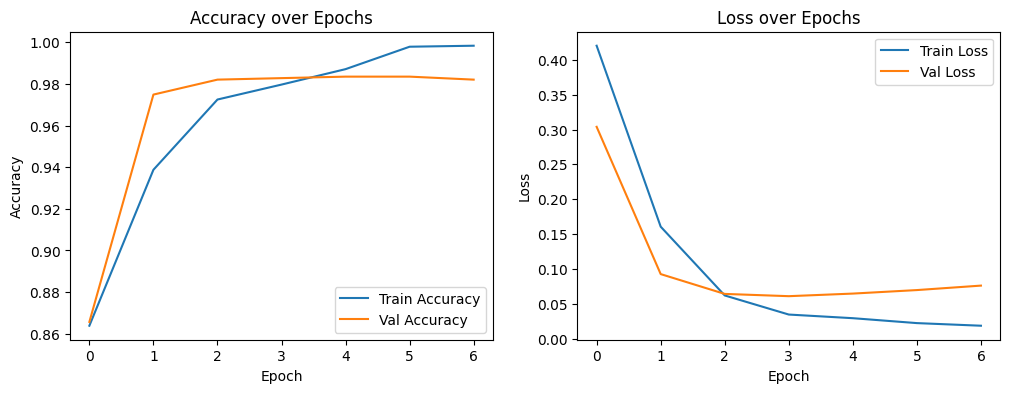

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      1205
        Spam       0.96      0.91      0.93       187

    accuracy                           0.98      1392
   macro avg       0.97      0.95      0.96      1392
weighted avg       0.98      0.98      0.98      1392



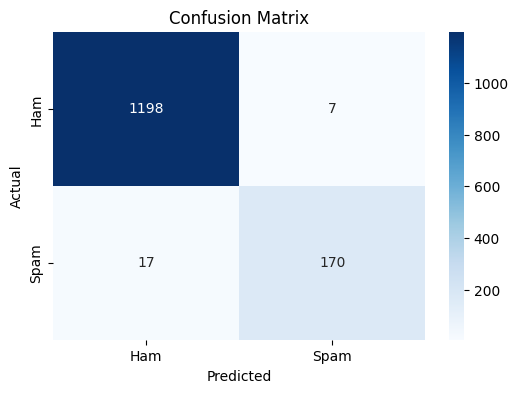

In [14]:
# Plot training history
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_history(history)

# Detailed Metrics
predictions_prob = model.predict(test_dataset).flatten()
predictions_classes = (predictions_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(test_labels, predictions_classes, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(test_labels, predictions_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **7: Prediction Function & FreeCodeCamp Test**


We create the ```predict_message``` function required by the challenge. I also added a bonus "pretty print" function so you can interact with your model like a real chat application!

In [15]:
# Function required by FreeCodeCamp
def predict_message(pred_text):
    # tf.convert_to_tensor ensures compatibility with Keras 3
    pred_prob = model.predict(tf.convert_to_tensor([pred_text]), verbose=0)[0][0]
    label = 'spam' if pred_prob >= 0.5 else 'ham'
    return [float(pred_prob), label]

# additional interactive function
def interactive_predict(pred_text):
    prob, label = predict_message(pred_text)
    confidence = prob * 100 if label == 'spam' else (1 - prob) * 100
    print(f"📩 Message: '{pred_text}'")
    print(f"🔍 Prediction: {label.upper()} ({confidence:.2f}% confidence)\n")

# Test it out!
interactive_predict("how are you doing today?")
interactive_predict("Congratulations! You've won a $1,000 Walmart gift card. Go to http://bit.ly/1234 to claim now.")


# FreeCodeCamp Test Suite (Do not modify)
def test_predictions():
  test_messages = ["how are you doing today",
                   "sale today! to stop texts call 98912460324",
                   "i dont want to go. can we try it a different day? available sat",
                   "our new mobile video service is live. just install on your phone to start watching.",
                   "you have won £1000 cash! call to claim your prize.",
                   "i'll bring it tomorrow. don't forget the milk.",
                   "wow, is your arm alright. that happened to me one time too"
                  ]

  test_answers = ["ham", "spam", "ham", "spam", "spam", "ham", "ham"]
  passed = True

  for msg, ans in zip(test_messages, test_answers):
    prediction = predict_message(msg)
    if prediction[1] != ans:
      passed = False

  if passed:
    print("✅ You passed the challenge. Great job!")
  else:
    print("❌ You haven't passed yet. Keep trying.")

test_predictions()

📩 Message: 'how are you doing today?'
🔍 Prediction: HAM (99.95% confidence)

📩 Message: 'Congratulations! You've won a $1,000 Walmart gift card. Go to http://bit.ly/1234 to claim now.'
🔍 Prediction: SPAM (96.81% confidence)

✅ You passed the challenge. Great job!
